In [1]:
import re

In [11]:
def extract_epoch_data(file_path):
    # Pattern to match the metrics in the line
    pattern = r"(?P<name>\w+)=?(?P<value>[\d.]+)"

    # Dictionary to store all metrics
    all_data = {}

    with open(file_path, 'r') as file:
        for line in file:
            # Extract epoch number
            epoch_match = re.search(r"Epoch (\d+):", line)
            if epoch_match:
                epoch_num = int(epoch_match.group(1))
                metrics = re.findall(pattern, line)
                
                # Add the data to the dictionary
                epoch_data = {}
                for name, value in metrics:
                    try: 
                        epoch_data[name] = float(value)
                    except: 
                        continue
                
                all_data[epoch_num] = epoch_data

    return all_data

In [46]:
# Use the function
file_path = "/home/gridsan/tmackey/cdvae/output/og_CDVAE_mp_20_v7_1_24127651_output.txt"
epoch_data = extract_epoch_data(file_path)

In [50]:
epoch_data

{0: {'10': 6.0,
  '0': 0.0,
  'loss': 41.7,
  'sw': 5.0,
  'val_loss': 118.0,
  'val_natom_loss': 3.05,
  'val_lattice_loss': 1.16,
  'val_coord_loss': 2.82,
  'val_type_loss': 89.4,
  'val_kld_loss': 0.237,
  'val_composition_loss': 4.64,
  'val_diffraction_loss': 0.0,
  'val_property_loss': 0.0,
  'val_natom_accuracy': 0.0371,
  'val_lengths_mard': 0.199,
  'val_angles_mae': 14.6,
  'val_volumes_mard': 0.387,
  'val_type_accuracy': 0.0117,
  'train_loss_step': 36.0,
  'train_natom_loss_step': 2.39,
  'train_lattice_loss_step': 0.718,
  'train_coord_loss_step': 1.07,
  'train_type_loss_step': 11.8,
  'train_kld_loss_step': 40.7,
  'train_composition_loss_step': 3.5,
  'train_diffraction_loss_step': 0.0},
 1: {'10': 6.0,
  '0': 0.0,
  'loss': 26.1,
  'sw': 5.0,
  'val_loss': 118.0,
  'val_natom_loss': 3.05,
  'val_lattice_loss': 1.16,
  'val_coord_loss': 2.82,
  'val_type_loss': 89.4,
  'val_kld_loss': 0.237,
  'val_composition_loss': 4.64,
  'val_diffraction_loss': 0.0,
  'val_propert

In [47]:
# Extract training and validation losses for plotting
epochs = list(epoch_data.keys())

In [48]:
train_losses = [epoch['loss'] for epoch in epoch_data.values()]  # Taking the last entry for each epoch
val_losses = [epoch['val_loss'] for epoch in epoch_data.values()]  # Taking the last entry for each epoch

In [57]:
train_losses = [epoch['loss'] for epoch in epoch_data.values() if epoch['loss'] <= 10]  # Filtering out values over 10
val_lattice_loss = [epoch['val_lattice_loss'] for epoch in epoch_data.values() if epoch['loss'] <= 10]
val_losses = [epoch['val_loss'] for epoch in epoch_data.values() if epoch['loss'] <= 20]  # Filtering out 0 values

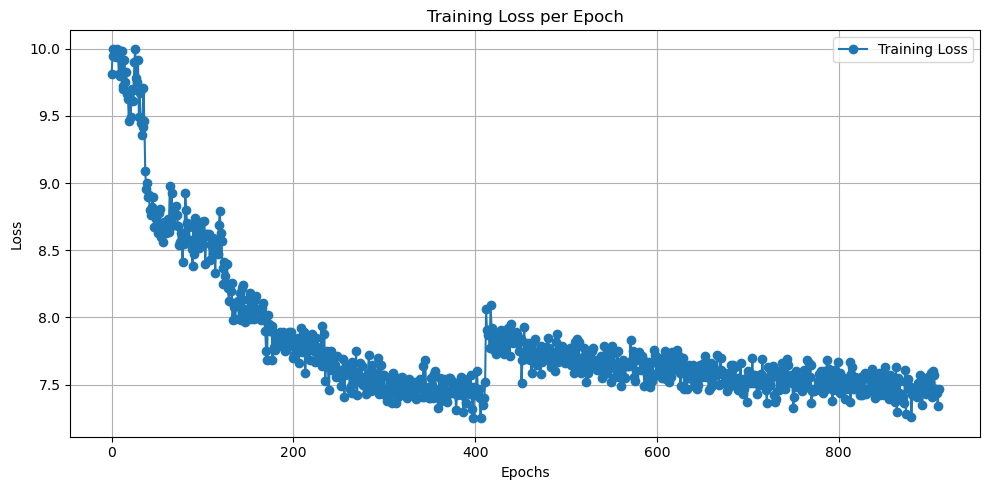

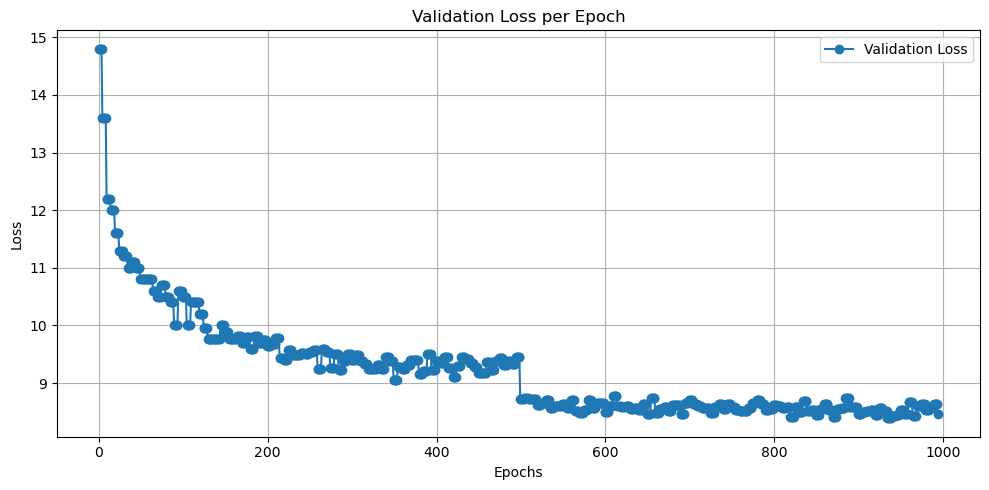

In [58]:
import matplotlib.pyplot as plt

# Plotting training losses
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label='Training Loss', marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting validation losses
plt.figure(figsize=(10, 5))
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss', marker='o')
plt.title("Validation Loss per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()